In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


from src.data_models.caravanify import Caravanify, CaravanifyConfig

In [3]:
sns.set_context("paper", font_scale=1.3)

---

In [4]:
CA_config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/shapefiles",
    human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="CA",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

CH_config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CH/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CH/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CH/post_processed/shapefiles",
    human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="CH",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

CL_config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CL/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CL/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CL/post_processed/shapefiles",
    human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="CL",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

USA_config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/USA/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/USA/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/USA/post_processed/shapefiles",
    human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="USA",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

In [5]:
CA_caravan = Caravanify(CA_config)
CH_caravan = Caravanify(CH_config)
CL_caravan = Caravanify(CL_config)
USA_caravan = Caravanify(USA_config)

CA_basins = CA_caravan.get_all_gauge_ids()
CH_basins = CH_caravan.get_all_gauge_ids()
CL_basins = CL_caravan.get_all_gauge_ids()
USA_basins = USA_caravan.get_all_gauge_ids()

basin_ids = CA_caravan.get_all_gauge_ids()
CA_caravan.load_stations(basin_ids)
CA_static_data = CA_caravan.get_static_attributes()

CA_gdf = CA_caravan.get_shapefiles()

CH_gdf = CH_caravan.get_shapefiles()
CH_gdf["country"] = "Switzerland"

CL_gdf = CL_caravan.get_shapefiles()
CL_gdf["country"] = "Chile"

USA_gdf = USA_caravan.get_shapefiles()
USA_gdf["country"] = "USA"

In [6]:
# Get the gauge_ids from static data where the country column is Kyrgyzstan
kgz_ids = CA_static_data[CA_static_data["country"] == "Kyrgyzstan"]["gauge_id"].unique()
print(f"Number of gauges in Kyrgyzstan: {len(kgz_ids)}")

# Same for Tajikistan
tjk_ids = CA_static_data[CA_static_data["country"] == "Tajikistan"]["gauge_id"].unique()
print(f"Number of gauges in Tajikistan: {len(tjk_ids)}")

# Add country column to gdt by mapping the gauge_id to the country
CA_gdf["country"] = CA_gdf["gauge_id"].map(
    CA_static_data.set_index("gauge_id")["country"]
)

Number of gauges in Kyrgyzstan: 62
Number of gauges in Tajikistan: 16


In [7]:
# # Concatenate all gdfs
all_gdfs = [CA_gdf, CH_gdf, CL_gdf, USA_gdf]
combined_gdf = pd.concat(all_gdfs, ignore_index=True)

# Drop rows with NaN in the country column
combined_gdf = combined_gdf[~combined_gdf["country"].isna()]

In [8]:
ids_CH = CH_caravan.get_all_gauge_ids()
ids_CA = CA_caravan.get_all_gauge_ids()
ids_CL = CL_caravan.get_all_gauge_ids()
ids_USA = USA_caravan.get_all_gauge_ids()

# Print the length of each list
print(f"Number of basins in CH: {len(ids_CH)}")
print(f"Number of basins in CA: {len(ids_CA)}")
print(f"Number of basins in CL: {len(ids_CL)}")
print(f"Number of basins in USA: {len(ids_USA)}")

Number of basins in CH: 135
Number of basins in CA: 78
Number of basins in CL: 505
Number of basins in USA: 671


---

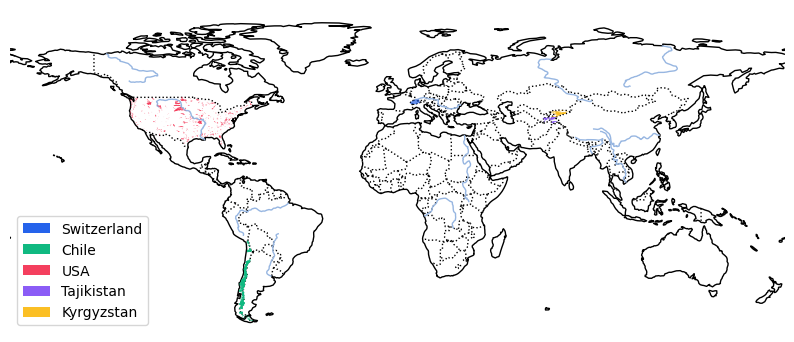

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sns.set_context("notebook", font_scale=1.3)

# Create figure and axes with a projection
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# Add base map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor='none')  # or adjust as needed
ax.add_feature(cfeature.OCEAN, facecolor='none')
ax.add_feature(cfeature.LAKES, facecolor='none')
ax.add_feature(cfeature.RIVERS, facecolor='none')

ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())


country_colors = {
    "Switzerland": "#2563EB",  # Vibrant Blue
    "Chile": "#10B981",        # Emerald Green
    "USA": "#F43F5E",          # Bright Rose
    "Tajikistan": "#8B5CF6",   # Purple
    "Kyrgyzstan": "#FBBF24",   # Amber Yellow
}

# Plot each basin with color based on country prefix
for idx, row in combined_gdf.iterrows():
    country = row["country"]
    
    color = country_colors.get(country, "gray")
    ax.add_geometries(
        [row.geometry],
        crs=ccrs.PlateCarree(),
        facecolor=color,
        edgecolor=None,
        alpha=1,
    )

# Add legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=color, edgecolor=None, alpha=1, label=country)
    for country, color in country_colors.items()
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=10)

for spine in ax.spines.values():
    spine.set_visible(False)
# Set title and adjust layout
# plt.title("Basin Shapefile Overview")
path_to_save = "/Users/cooper/Desktop/CAMELS-CH/images/Maps/world_map_all_basins.png"
plt.savefig(path_to_save, dpi=300, bbox_inches="tight")
plt.show()

In [10]:
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# from matplotlib.patches import FancyArrowPatch, Polygon
# import numpy as np
# import rasterio
# from rasterio.plot import show

# # Create figure and axes
# fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# # Load and plot hillshade layers for both countries
# # Replace these paths with your actual .tif file paths
# kyrgyzstan_hillshade_path = "/Users/cooper/Desktop/CAMELS-CH/data/Hillshade/KGZ_hillshade.tif"
# tajikistan_hillshade_path = "/Users/cooper/Desktop/CAMELS-CH/data/Hillshade/TJK_hillshade.tif"

# # Open the hillshade files
# with rasterio.open(kyrgyzstan_hillshade_path) as src1:
#     # Plot the hillshade with appropriate styling
#     show(src1, ax=ax, cmap="gray", alpha=0.5, transform=ccrs.PlateCarree())

# with rasterio.open(tajikistan_hillshade_path) as src2:
#     # Plot the hillshade with appropriate styling
#     show(src2, ax=ax, cmap="gray", alpha=0.5, transform=ccrs.PlateCarree())

# # Add cartography features
# ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
# ax.add_feature(cfeature.BORDERS, linewidth=0.5)
# ax.add_feature(cfeature.LAND, alpha=0.0)
# ax.add_feature(cfeature.OCEAN, alpha=0.0)
# ax.add_feature(cfeature.LAKES, alpha=0.0)

# # Plot CA basins with country-based coloring
# for country, color in country_colors.items():
#     country_basins = CA_gdf[CA_gdf["country"] == country]
#     if not country_basins.empty:
#         country_basins.plot(
#             ax=ax,
#             color=color,
#             edgecolor="black",
#             alpha=0.6,
#             linewidth=0.5,
#             label=country,
#         )

# # Add country labels for Central Asia
# ax.text(
#     74.7661,
#     41.2044,
#     "Kyrgyzstan",
#     transform=ccrs.PlateCarree(),
#     fontsize=10,
#     fontweight="bold",
#     ha="center",
# )
# ax.text(
#     71.2761,
#     38.8610,
#     "Tajikistan",
#     transform=ccrs.PlateCarree(),
#     fontsize=10,
#     fontweight="bold",
#     ha="center",
# )

# # Add gridlines with labels
# gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle="--")
# gl.top_labels = False
# gl.right_labels = False
# gl.xlabel_style = {"size": 10}
# gl.ylabel_style = {"size": 10}

# for spine in ax.spines.values():
#     spine.set_visible(False)

# # Set specific spines to be visible for axes
# ax.spines["left"].set_visible(True)  # y-axis
# ax.spines["bottom"].set_visible(True)  # x-axis

# arrow_x, arrow_y = 68.5, 42  # Position it in the top right
# arrow_length = 0.5

# # Create the arrow
# north_arrow = FancyArrowPatch(
#     (arrow_x, arrow_y),
#     (arrow_x, arrow_y + arrow_length),
#     transform=ccrs.PlateCarree(),
#     color="black",
#     linewidth=1,
#     arrowstyle="-|>",
#     mutation_scale=15,
# )
# ax.add_patch(north_arrow)

# # Add "N" label
# ax.text(
#     arrow_x,
#     arrow_y + arrow_length + 0.2,
#     "N",
#     transform=ccrs.PlateCarree(),
#     ha="center",
#     fontsize=10,
#     fontweight="bold",
# )

# ax_inset = fig.add_axes(
#     [0.75, 0.1, 0.2, 0.2], projection=ccrs.Orthographic(72, 40), zorder=5
# )

# # Add global features
# ax_inset.stock_img()  # This adds the NASA Blue Marble image as a background

# # Add coastlines and borders on top
# ax_inset.add_feature(cfeature.COASTLINE, linewidth=0.3)
# ax_inset.add_feature(cfeature.BORDERS, linewidth=0.2)

# # Create a polygon to highlight the region shown in the main map
# central_asia_extent = (67, 79, 37, 43)  # (min_lon, max_lon, min_lat, max_lat)
# min_lon, max_lon, min_lat, max_lat = central_asia_extent

# # Create the polygon vertices as a numpy array
# poly_verts = np.array(
#     [
#         [min_lon, min_lat],
#         [max_lon, min_lat],
#         [max_lon, max_lat],
#         [min_lon, max_lat],
#         [min_lon, min_lat],
#     ]
# )

# # Create and add the polygon
# poly = Polygon(
#     poly_verts,
#     transform=ccrs.PlateCarree(),
#     edgecolor="red",
#     facecolor="red",
#     alpha=1,
#     linewidth=1.5,
# )
# ax_inset.add_patch(poly)

# # Make the globe more complete by adjusting its appearance
# ax_inset.set_global()  # Show the full globe

# # Add a simple title to the inset map
# ax_inset.set_title("Location", fontsize=12)

# # Add a legend for countries
# ax.legend(loc="lower right", fontsize=10)

# plt.tight_layout()
# path_to_save = "/Users/cooper/Desktop/CAMELS-CH/images/Maps/CA_basins_by_country.png"
# plt.savefig(path_to_save, dpi=300, bbox_inches="tight")

# plt.show()